In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
folder = r"C:\Users\sneha\Downloads\Medical Provider Fraud Detection"

train_beneficiary = pd.read_csv(
    folder + r"\Train_Beneficiarydata.csv"
)

train_inpatient = pd.read_csv(
    folder + r"\Train_Inpatientdata.csv"
)

train_outpatient = pd.read_csv(
    folder + r"\Train_Outpatientdata.csv"
)

train_provider = pd.read_csv(
    folder + r"\Train.csv"
)

In [3]:
test_beneficiary = pd.read_csv(
    folder + r"\Test_Beneficiarydata.csv"
)

test_inpatient = pd.read_csv(
    folder + r"\Test_Inpatientdata.csv"
)

test_outpatient = pd.read_csv(
    folder + r"\Test_Outpatientdata.csv"
)

test_provider = pd.read_csv(
    folder + r"\Test.csv"
)

In [4]:
print("TRAIN")
print("Beneficiary:", train_beneficiary.shape)
print("Inpatient:", train_inpatient.shape)
print("Outpatient:", train_outpatient.shape)
print("Provider:", train_provider.shape)

print("\nTEST")
print("Beneficiary:", test_beneficiary.shape)
print("Inpatient:", test_inpatient.shape)
print("Outpatient:", test_outpatient.shape)
print("Provider:", test_provider.shape)

TRAIN
Beneficiary: (138556, 25)
Inpatient: (40474, 30)
Outpatient: (517737, 27)
Provider: (5410, 2)

TEST
Beneficiary: (63968, 25)
Inpatient: (9551, 30)
Outpatient: (125841, 27)
Provider: (1353, 1)


# Create Provider-Level Comparison Features

In [5]:
# Because we are comparing Train vs Test, we need the same provider-level metrics in both datasets.

# Train Provider Features

train_inpatient_claims = (
    train_inpatient
    .groupby("Provider")
    .agg(
        inpatient_claims=("ClaimID", "count"),
        inpatient_reimbursement=(
            "InscClaimAmtReimbursed",
            "sum"
        )
    )
    .reset_index()
)

train_outpatient_claims = (
    train_outpatient
    .groupby("Provider")
    .agg(
        outpatient_claims=("ClaimID", "count"),
        outpatient_reimbursement=(
            "InscClaimAmtReimbursed",
            "sum"
        )
    )
    .reset_index()
)

In [7]:
# Merge

train_provider_analysis = (
    train_provider[["Provider", "PotentialFraud"]]
    .merge(
        train_inpatient_claims,
        on="Provider",
        how="left"
    )
    .merge(
        train_outpatient_claims,
        on="Provider",
        how="left"
    )
)

In [8]:
# Fill missing values:

train_provider_analysis[
    [
        "inpatient_claims",
        "inpatient_reimbursement",
        "outpatient_claims",
        "outpatient_reimbursement"
    ]
] = train_provider_analysis[
    [
        "inpatient_claims",
        "inpatient_reimbursement",
        "outpatient_claims",
        "outpatient_reimbursement"
    ]
].fillna(0)

In [10]:
# Create totals:

train_provider_analysis["total_claims"] = (
    train_provider_analysis["inpatient_claims"]
    +
    train_provider_analysis["outpatient_claims"]
)

train_provider_analysis["total_reimbursement"] = (
    train_provider_analysis["inpatient_reimbursement"]
    +
    train_provider_analysis["outpatient_reimbursement"]
)

In [12]:
# Average reimbursement:

train_provider_analysis["avg_reimbursement"] = (
    train_provider_analysis["total_reimbursement"]
    /
    train_provider_analysis["total_claims"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# Create Test Provider Features

In [13]:
test_inpatient_claims = (
    test_inpatient
    .groupby("Provider")
    .agg(
        inpatient_claims=("ClaimID", "count"),
        inpatient_reimbursement=(
            "InscClaimAmtReimbursed",
            "sum"
        )
    )
    .reset_index()
)

In [14]:
test_outpatient_claims = (
    test_outpatient
    .groupby("Provider")
    .agg(
        outpatient_claims=("ClaimID", "count"),
        outpatient_reimbursement=(
            "InscClaimAmtReimbursed",
            "sum"
        )
    )
    .reset_index()
)

In [15]:
# Merge:

test_provider_analysis = (
    test_provider[["Provider"]]
    .merge(
        test_inpatient_claims,
        on="Provider",
        how="left"
    )
    .merge(
        test_outpatient_claims,
        on="Provider",
        how="left"
    )
)

In [16]:
# Fill missing:

test_provider_analysis[
    [
        "inpatient_claims",
        "inpatient_reimbursement",
        "outpatient_claims",
        "outpatient_reimbursement"
    ]
] = test_provider_analysis[
    [
        "inpatient_claims",
        "inpatient_reimbursement",
        "outpatient_claims",
        "outpatient_reimbursement"
    ]
].fillna(0)

In [18]:
# Create totals:

test_provider_analysis["total_claims"] = (
    test_provider_analysis["inpatient_claims"]
    +
    test_provider_analysis["outpatient_claims"]
)

test_provider_analysis["total_reimbursement"] = (
    test_provider_analysis["inpatient_reimbursement"]
    +
    test_provider_analysis["outpatient_reimbursement"]
)

test_provider_analysis["avg_reimbursement"] = (
    test_provider_analysis["total_reimbursement"]
    /
    test_provider_analysis["total_claims"]
).replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

# Does the Test dataset contain a provider population comparable to Train?

In [19]:
comparison_1 = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Providers": [
        train_provider_analysis["Provider"].nunique(),
        test_provider_analysis["Provider"].nunique()
    ]
})

comparison_1

,Dataset,Providers
0,Train,5410
1,Test,1353


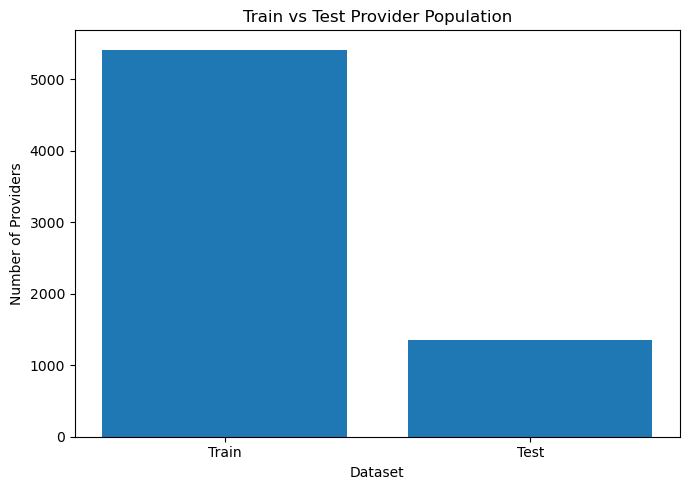

In [20]:
# Visualization
plt.figure(figsize=(7, 5))

plt.bar(
    comparison_1["Dataset"],
    comparison_1["Providers"]
)

plt.title("Train vs Test Provider Population")
plt.xlabel("Dataset")
plt.ylabel("Number of Providers")

plt.tight_layout()
plt.show()

In [ ]:
Answer: 

The provider population comparison establishes whether Train and Test have comparable coverage.
A broadly similar provider population indicates that the Test dataset is structurally suitable for applying patterns learned from Train.

# Do Train and Test providers generate similar numbers of claims?

In [21]:
claim_comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["total_claims"].mean(),
        train_provider_analysis["total_claims"].median(),
        train_provider_analysis["total_claims"].max()
    ],
    "Test": [
        test_provider_analysis["total_claims"].mean(),
        test_provider_analysis["total_claims"].median(),
        test_provider_analysis["total_claims"].max()
    ]
}, index=[
    "Mean Claims",
    "Median Claims",
    "Maximum Claims"
])

claim_comparison

,Train,Test
Mean Claims,103.181331,100.067997
Median Claims,31.000000,31.000000
Maximum Claims,8240.000000,3250.000000


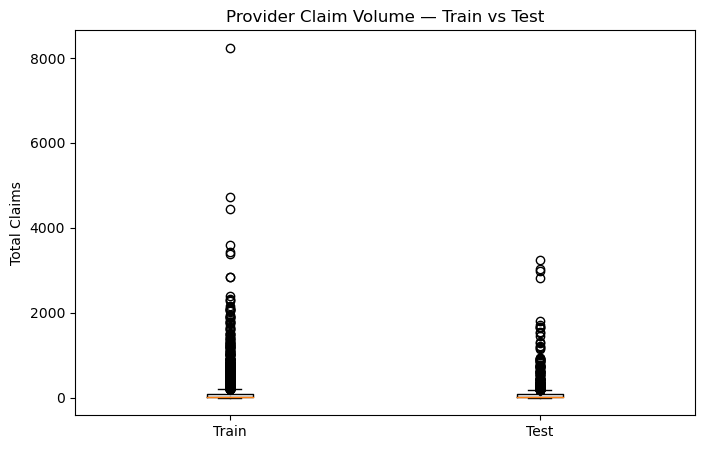

In [22]:
# Visualization
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train_provider_analysis["total_claims"],
        test_provider_analysis["total_claims"]
    ],
    labels=["Train", "Test"]
)

plt.title("Provider Claim Volume — Train vs Test")
plt.ylabel("Total Claims")

plt.show()

In [ ]:
Answer: 
Claim volume is a fundamental provider activity indicator.
Similar Train and Test distributions suggest that the operational intensity of providers is stable, while substantial differences may indicate population or sampling differences that should be considered before transferring risk thresholds

# Do Train and Test providers show comparable financial exposure?

In [23]:
reimbursement_comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["total_reimbursement"].mean(),
        train_provider_analysis["total_reimbursement"].median(),
        train_provider_analysis["total_reimbursement"].max()
    ],
    "Test": [
        test_provider_analysis["total_reimbursement"].mean(),
        test_provider_analysis["total_reimbursement"].median(),
        test_provider_analysis["total_reimbursement"].max()
    ]
}, index=[
    "Mean Reimbursement",
    "Median Reimbursement",
    "Maximum Reimbursement"
])

reimbursement_comparison

,Train,Test
Mean Reimbursement,1.028730e+05,9.819752e+04
Median Reimbursement,1.980500e+04,1.920000e+04
Maximum Reimbursement,5.996050e+06,6.097440e+06


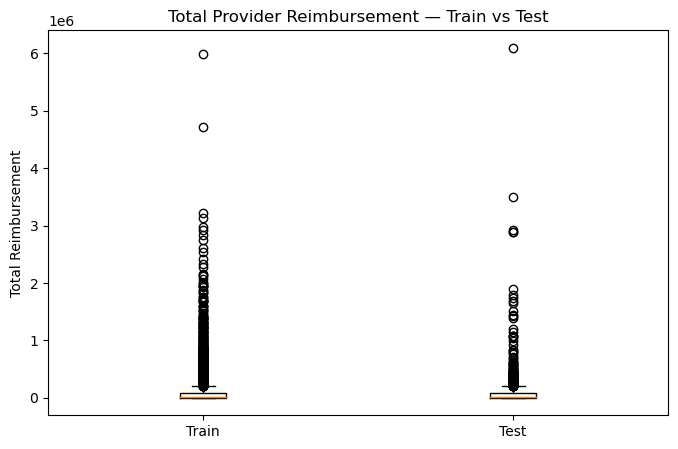

In [24]:
# Visualization
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train_provider_analysis["total_reimbursement"],
        test_provider_analysis["total_reimbursement"]
    ],
    labels=["Train", "Test"]
)

plt.title("Total Provider Reimbursement — Train vs Test")
plt.ylabel("Total Reimbursement")

plt.show()

In [ ]:
Answer

Comparing reimbursement distributions determines whether the financial scale of provider activity is consistent between Train and Test. Similar distributions support transferring reimbursement-based risk indicators, while large deviations may indicate distribution shift.

# Are individual claim amounts comparable between Train and Test?

In [25]:
avg_claim_comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["avg_reimbursement"].mean(),
        train_provider_analysis["avg_reimbursement"].median()
    ],
    "Test": [
        test_provider_analysis["avg_reimbursement"].mean(),
        test_provider_analysis["avg_reimbursement"].median()
    ]
}, index=[
    "Mean Average Claim",
    "Median Average Claim"
])

avg_claim_comparison

,Train,Test
Mean Average Claim,1740.679369,1701.078644
Median Average Claim,356.085106,366.727273


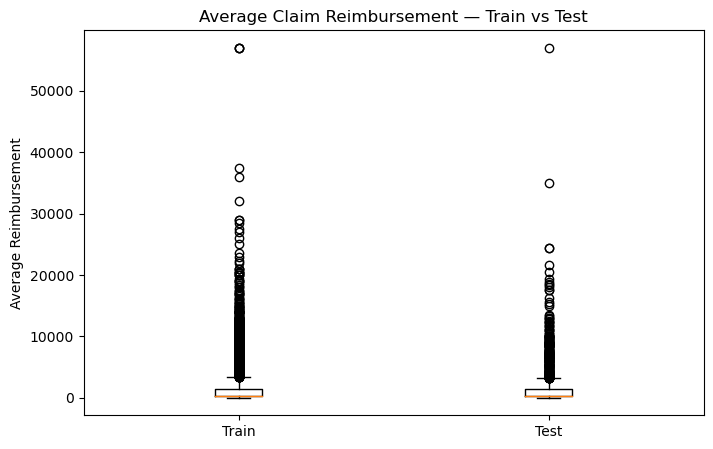

In [26]:
# Visualization:

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train_provider_analysis["avg_reimbursement"],
        test_provider_analysis["avg_reimbursement"]
    ],
    labels=["Train", "Test"]
)

plt.title("Average Claim Reimbursement — Train vs Test")
plt.ylabel("Average Reimbursement")

plt.show()

In [ ]:
Answer

Average reimbursement normalizes total financial exposure by claim volume. 
Similar Train and Test values indicate that claim-level financial intensity is relatively stable across datasets.

# Do Train and Test Have Similar Beneficiary Coverage?

In [41]:
# ============================================
# Q2. Do Train and Test providers serve
#     a similar number of beneficiaries?
# ============================================

# TRAIN
train_ip_bene = (
    train_inpatient
    .groupby("Provider")["BeneID"]
    .nunique()
)

train_op_bene = (
    train_outpatient
    .groupby("Provider")["BeneID"]
    .nunique()
)

train_beneficiaries = pd.concat(
    [train_ip_bene, train_op_bene],
    axis=1
).fillna(0)

train_beneficiaries["total_beneficiaries"] = (
    train_beneficiaries.iloc[:, 0]
    + train_beneficiaries.iloc[:, 1]
)

# TEST
test_ip_bene = (
    test_inpatient
    .groupby("Provider")["BeneID"]
    .nunique()
)

test_op_bene = (
    test_outpatient
    .groupby("Provider")["BeneID"]
    .nunique()
)

test_beneficiaries = pd.concat(
    [test_ip_bene, test_op_bene],
    axis=1
).fillna(0)

test_beneficiaries["total_beneficiaries"] = (
    test_beneficiaries.iloc[:, 0]
    + test_beneficiaries.iloc[:, 1]
)

# COMPARISON
beneficiary_comparison = pd.DataFrame({
    "Train": [
        train_beneficiaries["total_beneficiaries"].mean(),
        train_beneficiaries["total_beneficiaries"].median()
    ],
    "Test": [
        test_beneficiaries["total_beneficiaries"].mean(),
        test_beneficiaries["total_beneficiaries"].median()
    ]
}, index=[
    "Mean Beneficiaries per Provider",
    "Median Beneficiaries per Provider"
])

beneficiary_comparison.round(2)

,Train,Test
Mean Beneficiaries per Provider,67.92,65.18
Median Beneficiaries per Provider,25.00,25.00


In [42]:
# ============================================
# TRUE UNIQUE BENEFICIARIES PER PROVIDER
# ============================================

train_claims = pd.concat([
    train_inpatient[["Provider", "BeneID"]],
    train_outpatient[["Provider", "BeneID"]]
], ignore_index=True)

test_claims = pd.concat([
    test_inpatient[["Provider", "BeneID"]],
    test_outpatient[["Provider", "BeneID"]]
], ignore_index=True)

train_beneficiaries = (
    train_claims
    .groupby("Provider")["BeneID"]
    .nunique()
    .rename("unique_beneficiaries")
    .reset_index()
)

test_beneficiaries = (
    test_claims
    .groupby("Provider")["BeneID"]
    .nunique()
    .rename("unique_beneficiaries")
    .reset_index()
)

beneficiary_comparison = pd.DataFrame({
    "Train": [
        train_beneficiaries["unique_beneficiaries"].mean(),
        train_beneficiaries["unique_beneficiaries"].median()
    ],
    "Test": [
        test_beneficiaries["unique_beneficiaries"].mean(),
        test_beneficiaries["unique_beneficiaries"].median()
    ]
}, index=[
    "Mean Beneficiaries per Provider",
    "Median Beneficiaries per Provider"
])

beneficiary_comparison.round(2)

,Train,Test
Mean Beneficiaries per Provider,67.15,64.48
Median Beneficiaries per Provider,25.00,25.00


In [ ]:
Answer

Beneficiary coverage provides important context for provider activity.
Comparing beneficiary counts helps determine whether differences in claim volume are driven by differences in the patient population rather than provider billing behavior

# Create Beneficiaries 

In [60]:
train_inpatient_bene = (
    train_inpatient
    .groupby("Provider")["BeneID"]
    .nunique()
    .reset_index(name="inpatient_unique_beneficiaries")
)

train_outpatient_bene = (
    train_outpatient
    .groupby("Provider")["BeneID"]
    .nunique()
    .reset_index(name="outpatient_unique_beneficiaries")
)

In [61]:
train_beneficiary_comparison = pd.merge(
    train_inpatient_bene,
    train_outpatient_bene,
    on="Provider",
    how="outer"
)

train_beneficiary_comparison = train_beneficiary_comparison.fillna(0)

In [62]:
train_claims_combined = pd.concat(
    [
        train_inpatient[["Provider", "BeneID"]],
        train_outpatient[["Provider", "BeneID"]]
    ],
    ignore_index=True
)

train_unique_beneficiaries = (
    train_claims_combined
    .groupby("Provider")["BeneID"]
    .nunique()
    .reset_index(name="unique_beneficiaries")
)

In [63]:
test_claims_combined = pd.concat(
    [
        test_inpatient[["Provider", "BeneID"]],
        test_outpatient[["Provider", "BeneID"]]
    ],
    ignore_index=True
)

test_unique_beneficiaries = (
    test_claims_combined
    .groupby("Provider")["BeneID"]
    .nunique()
    .reset_index(name="unique_beneficiaries")
)

In [64]:
test_unique_beneficiaries.head()

,Provider,unique_beneficiaries
0,PRV51002,169
1,PRV51006,81
2,PRV51009,30
3,PRV51010,25
4,PRV51018,146


In [65]:
train_inpatient_claims = (
    train_inpatient
    .groupby("Provider")
    .agg(
        inpatient_claims=("ClaimID", "count"),
        inpatient_reimbursement=("InscClaimAmtReimbursed", "sum"),
        inpatient_avg_claim=("InscClaimAmtReimbursed", "mean")
    )
    .reset_index()
)

In [66]:
train_outpatient_claims = (
    train_outpatient
    .groupby("Provider")
    .agg(
        outpatient_claims=("ClaimID", "count"),
        outpatient_reimbursement=("InscClaimAmtReimbursed", "sum"),
        outpatient_avg_claim=("InscClaimAmtReimbursed", "mean")
    )
    .reset_index()
)

In [67]:
train_provider_analysis = pd.merge(
    train_inpatient_claims,
    train_outpatient_claims,
    on="Provider",
    how="outer"
)

train_provider_analysis = train_provider_analysis.fillna(0)

In [68]:
train_provider_analysis = pd.merge(
    train_provider_analysis,
    train_unique_beneficiaries,
    on="Provider",
    how="left"
)

train_provider_analysis["unique_beneficiaries"] = (
    train_provider_analysis["unique_beneficiaries"]
    .fillna(0)
)

In [69]:
train_provider_analysis["total_claims"] = (
    train_provider_analysis["inpatient_claims"]
    +
    train_provider_analysis["outpatient_claims"]
)

In [70]:
train_provider_analysis["total_claims"] = (
    train_provider_analysis["inpatient_claims"]
    +
    train_provider_analysis["outpatient_claims"]
)

In [71]:
train_provider_analysis["claims_per_beneficiary"] = (
    train_provider_analysis["total_claims"]
    /
    train_provider_analysis["unique_beneficiaries"].replace(0, np.nan)
)

train_provider_analysis["claims_per_beneficiary"] = (
    train_provider_analysis["claims_per_beneficiary"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [72]:
train_provider_analysis[
    [
        "Provider",
        "total_claims",
        "unique_beneficiaries",
        "claims_per_beneficiary"
    ]
].head()

,Provider,total_claims,unique_beneficiaries,claims_per_beneficiary
0,PRV51001,25.0,24,1.041667
1,PRV51003,132.0,117,1.128205
2,PRV51007,72.0,58,1.241379
3,PRV51008,43.0,36,1.194444
4,PRV51011,58.0,53,1.094340


In [88]:
test_inpatient_claims = (
    test_inpatient
    .groupby("Provider")
    .agg(
        inpatient_claims=("ClaimID", "count"),
        inpatient_reimbursement=("InscClaimAmtReimbursed", "sum"),
        inpatient_avg_claim=("InscClaimAmtReimbursed", "mean")
    )
    .reset_index()
)

In [89]:
test_outpatient_claims = (
    test_outpatient
    .groupby("Provider")
    .agg(
        outpatient_claims=("ClaimID", "count"),
        outpatient_reimbursement=("InscClaimAmtReimbursed", "sum"),
        outpatient_avg_claim=("InscClaimAmtReimbursed", "mean")
    )
    .reset_index()
)

In [90]:
test_provider_analysis = pd.merge(
    test_inpatient_claims,
    test_outpatient_claims,
    on="Provider",
    how="outer"
)

test_provider_analysis = test_provider_analysis.fillna(0)

In [91]:
test_provider_analysis = pd.merge(
    test_provider_analysis,
    test_unique_beneficiaries,
    on="Provider",
    how="left"
)

test_provider_analysis["unique_beneficiaries"] = (
    test_provider_analysis["unique_beneficiaries"]
    .fillna(0)
)

In [92]:
test_provider_analysis["total_claims"] = (
    test_provider_analysis["inpatient_claims"]
    +
    test_provider_analysis["outpatient_claims"]
)

In [93]:
test_provider_analysis["total_reimbursement"] = (
    test_provider_analysis["inpatient_reimbursement"]
    +
    test_provider_analysis["outpatient_reimbursement"]
)

In [94]:
test_provider_analysis["claims_per_beneficiary"] = (
    test_provider_analysis["total_claims"]
    /
    test_provider_analysis["unique_beneficiaries"].replace(0, np.nan)
)

test_provider_analysis["claims_per_beneficiary"] = (
    test_provider_analysis["claims_per_beneficiary"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [95]:
print("TRAIN COLUMNS")
print(train_provider_analysis.columns.tolist())

print("\nTEST COLUMNS")
print(test_provider_analysis.columns.tolist())

TRAIN COLUMNS
['Provider', 'inpatient_claims', 'inpatient_reimbursement', 'inpatient_avg_claim', 'outpatient_claims', 'outpatient_reimbursement', 'outpatient_avg_claim', 'unique_beneficiaries', 'total_claims', 'claims_per_beneficiary']

TEST COLUMNS
['Provider', 'inpatient_claims', 'inpatient_reimbursement', 'inpatient_avg_claim', 'outpatient_claims', 'outpatient_reimbursement', 'outpatient_avg_claim', 'unique_beneficiaries', 'total_claims', 'total_reimbursement', 'claims_per_beneficiary']


In [96]:
print(
    train_provider_analysis[
        [
            "Provider",
            "total_claims",
            "unique_beneficiaries",
            "claims_per_beneficiary"
        ]
    ].head()
)

   Provider  total_claims  unique_beneficiaries  claims_per_beneficiary
0  PRV51001          25.0                    24                1.041667
1  PRV51003         132.0                   117                1.128205
2  PRV51007          72.0                    58                1.241379
3  PRV51008          43.0                    36                1.194444
4  PRV51011          58.0                    53                1.094340


In [97]:
print(
    test_provider_analysis[
        [
            "Provider",
            "total_claims",
            "unique_beneficiaries",
            "claims_per_beneficiary"
        ]
    ].head()
)

   Provider  total_claims  unique_beneficiaries  claims_per_beneficiary
0  PRV51009          39.0                    30                1.300000
1  PRV51010          38.0                    25                1.520000
2  PRV51020          45.0                    38                1.184211
3  PRV51022         124.0                   103                1.203883
4  PRV51033          41.0                    41                1.000000


# Does provider utilization intensity remain consistent between Train and Test?

In [98]:
utilization_comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["claims_per_beneficiary"].mean(),
        train_provider_analysis["claims_per_beneficiary"].median()
    ],
    "Test": [
        test_provider_analysis["claims_per_beneficiary"].mean(),
        test_provider_analysis["claims_per_beneficiary"].median()
    ]
},
index=[
    "Mean Claims per Beneficiary",
    "Median Claims per Beneficiary"
])

utilization_comparison

,Train,Test
Mean Claims per Beneficiary,1.326886,1.325433
Median Claims per Beneficiary,1.098784,1.100000


In [99]:
# Interpretation


train_mean = train_provider_analysis["claims_per_beneficiary"].mean()
test_mean = test_provider_analysis["claims_per_beneficiary"].mean()

difference_pct = ((test_mean - train_mean) / train_mean) * 100

print(f"Train mean utilization: {train_mean:.2f}")
print(f"Test mean utilization: {test_mean:.2f}")
print(f"Difference: {difference_pct:.2f}%")

Train mean utilization: 1.33
Test mean utilization: 1.33
Difference: -0.11%


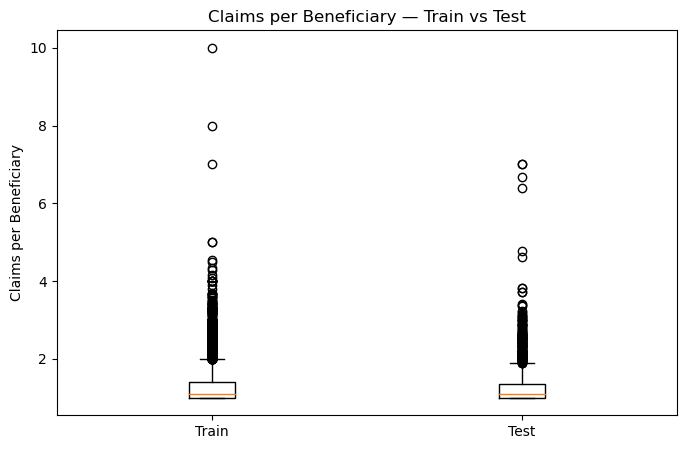

In [115]:
# Visualization
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        train_provider_analysis["claims_per_beneficiary"],
        test_provider_analysis["claims_per_beneficiary"]
    ],
    labels=["Train", "Test"]
)

plt.title("Claims per Beneficiary — Train vs Test")
plt.ylabel("Claims per Beneficiary")

plt.show()

In [ ]:
Answer

Claims per beneficiary is a normalized utilization indicator. 
If the Train and Test distributions are reasonably aligned, the provider-risk indicators based on utilization intensity can be transferred more confidently to Test.

# Do Train and Test providers have similar inpatient vs outpatient claim behavior?

In [101]:
# Create percentages:

train_provider_analysis["inpatient_claim_share"] = (
    train_provider_analysis["inpatient_claims"]
    /
    train_provider_analysis["total_claims"]
)

test_provider_analysis["inpatient_claim_share"] = (
    test_provider_analysis["inpatient_claims"]
    /
    test_provider_analysis["total_claims"]
)

In [102]:
comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["inpatient_claim_share"].mean(),
        1 - train_provider_analysis["inpatient_claim_share"].mean()
    ],
    "Test": [
        test_provider_analysis["inpatient_claim_share"].mean(),
        1 - test_provider_analysis["inpatient_claim_share"].mean()
    ]
},
index=[
    "Inpatient Claim Share",
    "Outpatient Claim Share"
])

comparison

,Train,Test
Inpatient Claim Share,0.144568,0.138276
Outpatient Claim Share,0.855432,0.861724


In [ ]:
Answer

The inpatient/outpatient mix indicates whether the type of healthcare utilization is consistent between Train and Test. 
A similar mix supports the assumption that the two datasets represent comparable provider activity.

# Are High-Cost Claims Distributed Similarly?

In [120]:
high_cost_threshold = train_inpatient[
    "InscClaimAmtReimbursed"
].quantile(0.95)

print("High-cost threshold:", high_cost_threshold)

High-cost threshold: 30000.0


In [121]:
train_high_cost = (
    train_inpatient[
        train_inpatient["InscClaimAmtReimbursed"]
        >= high_cost_threshold
    ]
    .groupby("Provider")
    .size()
    .reset_index(name="high_cost_claims")
)

test_high_cost = (
    test_inpatient[
        test_inpatient["InscClaimAmtReimbursed"]
        >= high_cost_threshold
    ]
    .groupby("Provider")
    .size()
    .reset_index(name="high_cost_claims")
)

In [122]:
# Merge:

train_provider_analysis = train_provider_analysis.merge(
    train_high_cost,
    on="Provider",
    how="left"
)

test_provider_analysis = test_provider_analysis.merge(
    test_high_cost,
    on="Provider",
    how="left"
)

train_provider_analysis["high_cost_claims"] = (
    train_provider_analysis["high_cost_claims"]
    .fillna(0)
)

test_provider_analysis["high_cost_claims"] = (
    test_provider_analysis["high_cost_claims"]
    .fillna(0)
)

In [123]:
# Compare:

high_cost_comparison = pd.DataFrame({
    "Train": [
        train_provider_analysis["high_cost_claims"].mean(),
        train_provider_analysis["high_cost_claims"].median()
    ],
    "Test": [
        test_provider_analysis["high_cost_claims"].mean(),
        test_provider_analysis["high_cost_claims"].median()
    ]
}, index=[
    "Mean High-Cost Claims",
    "Median High-Cost Claims"
])

high_cost_comparison

,Train,Test
Mean High-Cost Claims,0.393715,0.365115
Median High-Cost Claims,0.000000,0.000000


In [ ]:
Answer

High-cost claim behavior is particularly relevant to fraud-risk monitoring because unusually expensive claims increase financial exposure. The Train-derived threshold provides a consistent benchmark for evaluating Test without using Test information to define the threshold.